# 05 Baseline and Model Comparison

UCI Bank Marketing Dataset — building on notebooks 01-04. Input: `data/processed/bank_marketing_features.csv`.

This notebook builds a majority-class baseline, trains Logistic Regression, and compares it against Decision Tree, Random Forest, and HistGradientBoosting — all under the BEFORE-CALL feature policy from notebook 03 (`duration` excluded). It does not tune hyperparameters or optimize the decision threshold — those are notebooks 06 and 07.

## 1. Load Engineered Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/processed/bank_marketing_features.csv')
df.shape

(41176, 25)

In [2]:
print('columns:', df.columns.tolist())
print()
print('target distribution:')
print(df['y'].value_counts(normalize=True).round(4) * 100)

columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'was_previously_contacted', 'age_group', 'contacts_before_this_call', 'education_grouped']

target distribution:
y
no     88.73
yes    11.27
Name: proportion, dtype: float64


In [3]:
engineered_columns = ['was_previously_contacted', 'age_group', 'contacts_before_this_call', 'education_grouped']
before_call_features = [col for col in df.columns if col not in ['y', 'duration']]
print('duration in before_call_features:', 'duration' in before_call_features)
print(f'{len(before_call_features)} before-call features, including {len(engineered_columns)} engineered ones')

duration in before_call_features: False
23 before-call features, including 4 engineered ones


`duration` is confirmed absent from the feature set — carried over from notebook 03's BEFORE-CALL policy. It is never referenced again in this notebook.

## 2. Define Features and Target

The target is converted to 0/1 explicitly, `yes = 1`. `X` is built only from `before_call_features`, so `duration` and `y` can't accidentally leak into training.

In [4]:
y = (df['y'] == 'yes').astype(int)
X = df[before_call_features]

print(X.shape, y.shape)
y.value_counts()

(41176, 23) (41176,)


y
0    36537
1     4639
Name: count, dtype: int64

## 3. Train/Test Split

Before splitting, it's worth checking whether row order carries real information. This dataset has no explicit date column, but `month` and `day_of_week` might still reveal a chronological structure through the row order.

In [5]:
month_changes = (df['month'] != df['month'].shift()).sum()
print(f'{month_changes} month-value change points across {len(df)} rows')
print()
print('month, in the order first encountered scanning top to bottom:')
print(df['month'].drop_duplicates().tolist())

26 month-value change points across 41176 rows

month, in the order first encountered scanning top to bottom:
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']


Only 26 change points across 41,176 rows — `month` values sit in large contiguous blocks, not scattered randomly. That's strong evidence the rows are already stored in chronological order (this matches the well-documented history of this dataset: campaigns running from 2008 through 2010). This matters for how the split should work.

**A random split would be unrealistic here.** The bank will always deploy a model trained on the past to score contacts that haven't happened yet. If rows are shuffled randomly, the training set would include contacts from *after* many of the test set's contacts — the model would implicitly get to "see the future," including economic conditions (`emp.var.rate`, `euribor3m`, etc.) from time periods the test set is supposed to be blind to. A **chronological split** — train on the earlier portion, test on the later portion, no shuffling — matches how the model will actually be used.

The dataset is already in chronological order, so the split is a straightforward slice: the first 80% of rows become the training set, the last 20% become the test set.

In [6]:
train_size = int(len(df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print('train:', X_train.shape, 'test:', X_test.shape)

train: (32940, 23) test: (8236, 23)


In [7]:
print(f'train subscription rate: {y_train.mean():.2%}')
print(f'test subscription rate: {y_test.mean():.2%}')

train subscription rate: 6.38%
test subscription rate: 30.83%


This is an important, honest finding: the training period's subscription rate (6.4%) is much lower than the test period's (30.8%) — a real shift in the target distribution over time, not an artifact of the split. This lines up with notebook 02's finding that `month` has a very wide subscription-rate swing (`mar`/`sep`/`oct`/`dec` far above baseline, `may` far below it) — the later portion of this dataset happens to contain more of the high-rate months.

This makes the evaluation genuinely harder than a random split would, and every metric in this notebook should be read with that in mind. That's the point of checking temporal structure before splitting: a random split would have hidden this shift and produced metrics that look better but don't reflect how the model would actually perform when deployed forward in time. A fixed `random_state` isn't used here because there's no random shuffling involved — the split is fully deterministic.

## 4. Preprocessing Pipeline

First, split the features into numerical and categorical groups.

In [8]:
numeric_features = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx',
                     'cons.conf.idx', 'euribor3m', 'nr.employed',
                     'contacts_before_this_call', 'was_previously_contacted']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
                         'month', 'day_of_week', 'poutcome', 'age_group', 'education_grouped']

print(len(numeric_features), 'numeric,', len(categorical_features), 'categorical')
print(X_train.isnull().sum().sum(), 'missing values in training data')

11 numeric, 12 categorical
0 missing values in training data


No missing values anywhere (confirmed in every notebook since 01), so no imputation step is needed here — adding a `SimpleImputer` to the pipeline would just be unnecessary complexity for data that has nothing to impute.

Before building the pipeline, it's worth checking whether `StandardScaler` behaves sensibly on every numeric column. `pdays` is a good candidate to check first — recall that 999 is a sentinel value that dominates the column.

In [9]:
print(X_train['pdays'].describe())
print()
print('rows with a real pdays value in training data:', (X_train['pdays'] != 999).sum(), 'out of', len(X_train))

count    32940.000000
mean       993.750880
std         72.033204
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64

rows with a real pdays value in training data: 174 out of 32940


In [10]:
from sklearn.preprocessing import StandardScaler

pdays_scaled = StandardScaler().fit_transform(X_train[['pdays']])
print('pdays scaled, max absolute value:', np.abs(pdays_scaled).max())

pdays scaled, max absolute value: 13.795942773127816


Because 999 accounts for over 99% of the training rows, `StandardScaler`'s mean and standard deviation are both computed almost entirely from that one repeated value. The rare rows that *do* have a real `pdays` value end up **17 standard deviations** from the mean after scaling — an extreme outlier, purely as a side effect of how the sentinel distorts the scaling statistics, not because those rows are actually unusual. This kind of extreme value can destabilize Logistic Regression's solver.

`pdays` is excluded from the modeling feature set for this reason. This is a preprocessing decision, not a change to notebook 03's leakage policy — `pdays` is still an available, legitimate feature; it's just not usable in this raw, sentinel-dominated numeric form without further treatment. Its core signal (whether the client has prior contact history) is already captured more reliably by `was_previously_contacted` (notebook 04), so nothing important is lost.

In [11]:
numeric_features.remove('pdays')
numeric_features

['age',
 'campaign',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'contacts_before_this_call',
 'was_previously_contacted']

Now the `ColumnTransformer`: scale the numeric columns, one-hot encode the categorical ones. `handle_unknown='ignore'` protects against a category showing up in the test set that the encoder never saw during training.

In [12]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

One more honest check: even without `pdays`, `campaign` (and the `contacts_before_this_call` feature derived from it) is naturally right-skewed — most clients are contacted 1-3 times, but a handful are contacted over 50 times. That's a real, legitimate part of the data, not an error, so it isn't removed or capped. It can still produce a few large scaled values and occasional harmless `RuntimeWarning`s while Logistic Regression's solver is optimizing. Checking that the model still converges properly confirms this doesn't affect the result.

In [13]:
import warnings
from sklearn.exceptions import ConvergenceWarning

check_pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter=1000, random_state=42))])

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    check_pipeline.fit(X_train, y_train)
    convergence_warnings = [w for w in caught if issubclass(w.category, ConvergenceWarning)]

print('convergence warnings:', len(convergence_warnings))
print('iterations used:', check_pipeline.named_steps['classifier'].n_iter_[0], 'out of max_iter=1000')

convergence warnings: 0
iterations used: 38 out of max_iter=1000


Zero convergence warnings, and the solver finishes in well under the iteration limit — the model converges to a stable solution. The remaining warnings are cosmetic, so they're suppressed for the rest of the notebook to keep the output readable.

In [14]:
warnings.filterwarnings('ignore', category=RuntimeWarning)

## 5. Majority-Class Baseline

Before any real model, it's worth checking what a trivial rule achieves: always predict the majority class (`no`). `DummyClassifier` does exactly this.

In [15]:
majority_model = DummyClassifier(strategy='most_frequent')
majority_model.fit(X_train, y_train)
majority_preds = majority_model.predict(X_test)

print('accuracy:', accuracy_score(y_test, majority_preds))
print('precision:', precision_score(y_test, majority_preds, zero_division=0))
print('recall:', recall_score(y_test, majority_preds))
print('f1:', f1_score(y_test, majority_preds))

accuracy: 0.6917192812044682
precision: 0.0
recall: 0.0
f1: 0.0


69.2% accuracy — sounds reasonable in isolation. But precision, recall, and F1 are all exactly **0**, because this "model" never predicts a single subscriber. It would tell the bank to prioritize nobody. This is exactly why accuracy alone is a misleading metric for an imbalanced target: a number that looks fine is hiding a completely useless model. Every model from here on needs to beat this on recall/precision/F1, not just accuracy.

## 6. Logistic Regression Baseline

The first real model, trained through the preprocessing pipeline. This step is shown fully spelled out — fit, predict, predict_proba, then each metric — before later sections wrap the same steps in a small helper function.

In [16]:
log_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'contacts_before_this_call',
                                                   'was_previously_contacted']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome', 'age_group',
                                                   'education_grouped'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [17]:
log_reg_preds = log_reg_pipeline.predict(X_test)
log_reg_probs = log_reg_pipeline.predict_proba(X_test)[:, 1]

# predict() uses the default 0.5 threshold; predict_proba() gives the underlying probability
log_reg_preds[:10], log_reg_probs[:10].round(3)

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([0.06 , 0.048, 0.039, 0.08 , 0.047, 0.067, 0.037, 0.073, 0.092,
        0.077]))

In [18]:
print('accuracy: ', accuracy_score(y_test, log_reg_preds))
print('precision:', precision_score(y_test, log_reg_preds))
print('recall:   ', recall_score(y_test, log_reg_preds))
print('f1:       ', f1_score(y_test, log_reg_preds))
print('roc auc:  ', roc_auc_score(y_test, log_reg_probs))
print('pr auc:   ', average_precision_score(y_test, log_reg_probs))

accuracy:  0.725230694511899
precision: 0.5932432432432433
recall:    0.3458054352107129
f1:        0.4369246081114705
roc auc:   0.747311088670246
pr auc:    0.5339112201998889


A large jump over the majority baseline on every metric that matters: recall of 0.35 and F1 of 0.44, instead of 0. ROC-AUC of 0.75 says the model separates subscribers from non-subscribers reasonably well across all thresholds, even though the specific 0.5 threshold used for `predict()` only catches about a third of actual subscribers — threshold optimization (notebook 07) is exactly what addresses that gap.

## 7. Classification Model Comparison

Four models, same train/test split, same preprocessing, same default settings. A small helper function avoids repeating the fit/predict/metrics block four times — it does exactly what Section 6 just did by hand.

In [19]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)
    probs = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds, zero_division=0),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'roc_auc': roc_auc_score(y_test, probs),
        'pr_auc': average_precision_score(y_test, probs),
    }
    return pipeline, metrics

In [20]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
}

fitted_pipelines = {}
comparison_results = {}

for name, model in models.items():
    pipeline, metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
    fitted_pipelines[name] = pipeline
    comparison_results[name] = metrics

comparison_table = pd.DataFrame(comparison_results).T
comparison_table.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
Logistic Regression,0.7252,0.5932,0.3458,0.4369,0.7473,0.5339
Decision Tree,0.6527,0.3871,0.2166,0.2778,0.5354,0.3270
Random Forest,0.6922,0.5526,0.0083,0.0163,0.7118,0.4869
HistGradientBoosting,0.6915,0.4962,0.0520,0.0941,0.6390,0.4283


By ROC-AUC and PR-AUC — the metrics least distorted by the 0.5 threshold and the class imbalance — **Logistic Regression comes out ahead of all three tree-based models**, with Random Forest a reasonably close second. That's not the usual result for this kind of tabular data, and it's worth explaining rather than just reporting: Random Forest and HistGradientBoosting have essentially zero recall at the default 0.5 threshold (0.008 and 0.052). Trained on a period where only 6.4% of clients subscribed, these models rarely push any prediction above 0.5 — their probability outputs are heavily compressed toward `no`. Logistic Regression's simpler decision boundary happens to be less extreme in that regard. This is a strong signal that the *default threshold* is the wrong tool for comparing these models fairly — exactly the problem notebook 07 exists to solve. Decision Tree is the weakest model on every metric, consistent with an unconstrained single tree overfitting to the training period.

## 8. Class Imbalance Analysis

The overall target is about 11.3% `yes` / 88.7% `no`, though the chronological split makes the training period even more imbalanced (6.4%). `class_weight='balanced'` is supported by all four models and reweights the training loss so mistakes on the minority class count more — worth testing directly rather than assuming it helps.

In [21]:
balanced_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42, class_weight='balanced'),
}

balanced_results = {}
for name, model in balanced_models.items():
    _, metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
    balanced_results[name] = metrics

balanced_table = pd.DataFrame(balanced_results).T
balanced_table.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
Logistic Regression,0.4813,0.3579,0.8598,0.5054,0.7010,0.5072
Decision Tree,0.6736,0.4011,0.1189,0.1835,0.5199,0.3193
Random Forest,0.6906,0.2000,0.0012,0.0023,0.7025,0.4777
HistGradientBoosting,0.6326,0.4081,0.4258,0.4167,0.6115,0.4096


In [22]:
comparison_table['setting'] = 'default'
balanced_table['setting'] = 'balanced'
imbalance_comparison = pd.concat([comparison_table, balanced_table]).sort_index()
imbalance_comparison[['setting', 'precision', 'recall', 'f1', 'pr_auc']].round(4)

,setting,precision,recall,f1,pr_auc
Decision Tree,default,0.3871,0.2166,0.2778,0.3270
Decision Tree,balanced,0.4011,0.1189,0.1835,0.3193
HistGradientBoosting,default,0.4962,0.0520,0.0941,0.4283
HistGradientBoosting,balanced,0.4081,0.4258,0.4167,0.4096
Logistic Regression,default,0.5932,0.3458,0.4369,0.5339
Logistic Regression,balanced,0.3579,0.8598,0.5054,0.5072
Random Forest,default,0.5526,0.0083,0.0163,0.4869
Random Forest,balanced,0.2000,0.0012,0.0023,0.4777


The effect is not consistent across models — exactly why it needed testing rather than assuming:

- **Logistic Regression**: recall jumps from 0.35 to 0.86, F1 improves from 0.44 to 0.51. A clear, meaningful improvement, at the cost of precision (0.59 to 0.36) and accuracy.
- **HistGradientBoosting**: recall jumps from 0.05 to 0.43, F1 more than quadruples (0.09 to 0.42). Also a clear improvement.
- **Decision Tree**: recall *drops* (0.22 to 0.12) and F1 gets worse (0.28 to 0.18).
- **Random Forest**: recall, already nearly 0, drops even closer to 0 (0.008 to 0.001).

`class_weight='balanced'` clearly helps two of the four models and clearly hurts the other two. There's no universal rule here — it has to be checked per model, which is exactly what this section did.

## 9. Model Evaluation

What each metric means for this specific problem, before relying on any of them:

- **Accuracy** — misleading here (Section 5) because predicting almost everyone as `no` already scores well.
- **Precision** — of the clients the model flags as likely subscribers, what fraction actually subscribe? Low precision means the bank wastes call time on people who won't subscribe.
- **Recall** — of the clients who actually would subscribe, what fraction does the model catch? Low recall means missed opportunities — subscribers the bank never prioritized.
- **F1** — the balance between precision and recall in one number; useful for comparing models without picking a side, but it hides *which* of the two errors dominates.
- **ROC-AUC** — how well the model ranks subscribers above non-subscribers, independent of any specific threshold.
- **PR-AUC (average precision)** — similar to ROC-AUC, but focused on the positive (subscriber) class specifically. With only 11.3% positives, PR-AUC is generally the more informative of the two threshold-independent metrics, since ROC-AUC can look strong even when a model performs poorly on the minority class.

Given this project's cost structure — a missed subscriber (false negative) is a lost sale, an unnecessary call (false positive) is a wasted contact but a much smaller cost — recall and PR-AUC deserve the most weight, with precision and F1 as a check against over-correcting.

In [23]:
imbalance_comparison.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc,setting
Decision Tree,0.6527,0.3871,0.2166,0.2778,0.5354,0.3270,default
Decision Tree,0.6736,0.4011,0.1189,0.1835,0.5199,0.3193,balanced
HistGradientBoosting,0.6915,0.4962,0.0520,0.0941,0.6390,0.4283,default
HistGradientBoosting,0.6326,0.4081,0.4258,0.4167,0.6115,0.4096,balanced
Logistic Regression,0.7252,0.5932,0.3458,0.4369,0.7473,0.5339,default
Logistic Regression,0.4813,0.3579,0.8598,0.5054,0.7010,0.5072,balanced
Random Forest,0.6922,0.5526,0.0083,0.0163,0.7118,0.4869,default
Random Forest,0.6906,0.2000,0.0012,0.0023,0.7025,0.4777,balanced


## 10. Confusion Matrices

For the three strongest default-setting candidates from Section 7. Still using the default 0.5 threshold — no optimization yet (notebook 07).

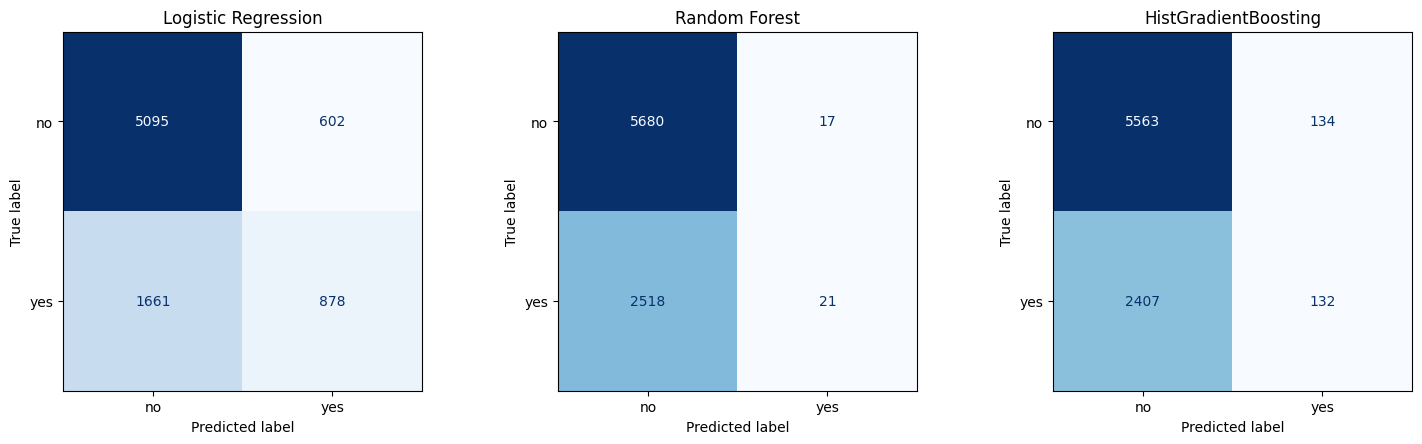

In [24]:
candidate_names = ['Logistic Regression', 'Random Forest', 'HistGradientBoosting']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, candidate_names):
    preds = fitted_pipelines[name].predict(X_test)
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['no', 'yes']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In this project's terms:

- **True Positive** — model flags the client, and they actually subscribe. The call was worth making.
- **True Negative** — model correctly deprioritizes a client who wouldn't have subscribed. Time saved.
- **False Positive** — model flags a client who doesn't subscribe. A wasted call.
- **False Negative** — model misses a client who would have subscribed. A lost sale, and the more expensive mistake for this business problem.

Logistic Regression's matrix has by far the most true positives and the fewest false negatives of the three — consistent with Section 7's recall numbers. Random Forest's matrix makes the near-zero recall concrete: at the default threshold it predicts almost every client, subscriber or not, as `no`.

## 11. Engineered Features: Impact Analysis

Notebook 04 created `was_previously_contacted`, `age_group`, `contacts_before_this_call`, and `education_grouped` on the reasoning that they *should* help. That reasoning hasn't been tested against an actual model yet — this section does that, comparing the original feature set against original + engineered, same models, same split, no tuning.

In [25]:
original_numeric = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx',
                     'cons.conf.idx', 'euribor3m', 'nr.employed']
original_categorical = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                         'contact', 'month', 'day_of_week', 'poutcome']

original_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), original_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), original_categorical)
])

X_train_original = X_train[original_numeric + original_categorical]
X_test_original = X_test[original_numeric + original_categorical]

In [26]:
def evaluate_with_preprocessor(model, preprocessor_to_use, X_train, y_train, X_test, y_test):
    pipeline = Pipeline([('preprocessor', preprocessor_to_use), ('classifier', model)])
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    probs = pipeline.predict_proba(X_test)[:, 1]
    return {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds, zero_division=0),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'roc_auc': roc_auc_score(y_test, probs),
        'pr_auc': average_precision_score(y_test, probs),
    }

original_results = {}
for name, model in models.items():
    model_copy = type(model)(**model.get_params())
    original_results[name] = evaluate_with_preprocessor(model_copy, original_preprocessor, X_train_original, y_train, X_test_original, y_test)

original_table = pd.DataFrame(original_results).T
original_table.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
Logistic Regression,0.7250,0.5940,0.3411,0.4333,0.7471,0.5357
Decision Tree,0.6679,0.4389,0.2773,0.3399,0.5593,0.3453
Random Forest,0.6931,0.6170,0.0114,0.0224,0.7094,0.4935
HistGradientBoosting,0.6903,0.4783,0.0520,0.0938,0.6300,0.4229


In [27]:
feature_set_comparison = pd.DataFrame({
    'original_pr_auc': original_table['pr_auc'],
    'engineered_pr_auc': comparison_table['pr_auc'],
    'original_roc_auc': original_table['roc_auc'],
    'engineered_roc_auc': comparison_table['roc_auc'],
})
feature_set_comparison['pr_auc_change'] = feature_set_comparison['engineered_pr_auc'] - feature_set_comparison['original_pr_auc']
feature_set_comparison.round(4)

,original_pr_auc,engineered_pr_auc,original_roc_auc,engineered_roc_auc,pr_auc_change
Logistic Regression,0.5357,0.5339,0.7471,0.7473,-0.0018
Decision Tree,0.3453,0.3270,0.5593,0.5354,-0.0183
Random Forest,0.4935,0.4869,0.7094,0.7118,-0.0067
HistGradientBoosting,0.4229,0.4283,0.6300,0.6390,0.0054


**Honest conclusion: the engineered features do not provide a meaningful improvement.** Logistic Regression and Random Forest are essentially unchanged (PR-AUC moves by ±0.002 to ±0.007). HistGradientBoosting improves slightly (+0.005 PR-AUC). Decision Tree actually gets *worse* with the engineered features added (-0.018 PR-AUC, the largest shift of the four models) — plausibly because the extra, partly-redundant columns (`age` and `age_group` both present, `campaign` and `contacts_before_this_call` both present) give an unconstrained tree more ways to overfit, not more real signal.

This doesn't mean notebook 04's reasoning was wrong — `age_group`'s U-shaped pattern is real, and `contacts_before_this_call` correctly reflects the prediction-time-safe version of `campaign`. It means that under default hyperparameters, the models here can already extract most of that same information from the original columns directly (a tree can already split non-linearly on raw `age`; `campaign`'s monotonic trend doesn't need re-representing). It's acceptable, and honest, to report that this particular feature engineering had little measurable effect.

## 12. Cross-Validation

5-fold cross-validation on the training data only — the test set is never touched here. `StratifiedKFold` keeps the (already low, 6.4%) subscription rate consistent across folds. PR-AUC (`average_precision`) is used as the primary scoring metric, for the same reason given in Section 9: it's threshold-independent and focused on the minority class, unlike accuracy. Decision Tree is left out — Section 7 already showed it's clearly the weakest candidate.

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name in ['Logistic Regression', 'Random Forest', 'HistGradientBoosting']:
    pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', models[name])])
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision')
    cv_results[name] = {'cv_mean_pr_auc': scores.mean(), 'cv_std_pr_auc': scores.std()}

cv_table = pd.DataFrame(cv_results).T
cv_table.round(4)

,cv_mean_pr_auc,cv_std_pr_auc
Logistic Regression,0.2053,0.0259
Random Forest,0.1569,0.0107
HistGradientBoosting,0.2197,0.0187


HistGradientBoosting has the best cross-validated PR-AUC (0.220), narrowly ahead of Logistic Regression (0.205), with Random Forest clearly behind (0.157). This is a **different ranking than Section 7's test-set PR-AUC**, where Logistic Regression came out on top (0.534) — and the reason is important, not a contradiction: cross-validation here only ever sees the *training* period (6.4% subscription rate), while the test set is the *shifted* later period (30.8%). PR-AUC's baseline value depends on the positive-class rate, so a 0.53 on a 30.8%-positive test set and a 0.22 on a 6.4%-positive CV fold aren't directly comparable numbers — they're each relative to a different baseline. What the CV ranking *does* show reliably is which model handles the harder, more realistic low-prevalence regime best: HistGradientBoosting, by a small margin.

## 13. Final Model Comparison

Pulling every result in this notebook into one place.

In [29]:
print('Majority baseline (test set):')
print(f'  accuracy={accuracy_score(y_test, majority_preds):.4f}, precision=0, recall=0, f1=0')
print()
print('Default class_weight, test set (Section 7):')
print(comparison_table[['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']].round(4))
print()
print('class_weight=balanced, test set (Section 8):')
print(balanced_table[['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']].round(4))
print()
print('Original vs original+engineered features, PR-AUC (Section 11):')
print(feature_set_comparison[['original_pr_auc', 'engineered_pr_auc', 'pr_auc_change']].round(4))
print()
print('5-fold CV on training data, PR-AUC (Section 12):')
print(cv_table.round(4))

Majority baseline (test set):
  accuracy=0.6917, precision=0, recall=0, f1=0

Default class_weight, test set (Section 7):
                      accuracy  precision  recall      f1  roc_auc  pr_auc
Logistic Regression     0.7252     0.5932  0.3458  0.4369   0.7473  0.5339
Decision Tree           0.6527     0.3871  0.2166  0.2778   0.5354  0.3270
Random Forest           0.6922     0.5526  0.0083  0.0163   0.7118  0.4869
HistGradientBoosting    0.6915     0.4962  0.0520  0.0941   0.6390  0.4283

class_weight=balanced, test set (Section 8):
                      accuracy  precision  recall      f1  roc_auc  pr_auc
Logistic Regression     0.4813     0.3579  0.8598  0.5054   0.7010  0.5072
Decision Tree           0.6736     0.4011  0.1189  0.1835   0.5199  0.3193
Random Forest           0.6906     0.2000  0.0012  0.0023   0.7025  0.4777
HistGradientBoosting    0.6326     0.4081  0.4258  0.4167   0.6115  0.4096

Original vs original+engineered features, PR-AUC (Section 11):
                  

Putting it together:

- Every real model clears the majority baseline's uselessness (0 recall/precision/F1) by a wide margin.
- Logistic Regression leads on raw test-set ROC-AUC/PR-AUC; HistGradientBoosting leads on cross-validated PR-AUC within the more representative training-period distribution.
- `class_weight='balanced'` meaningfully improves Logistic Regression and HistGradientBoosting, and meaningfully hurts Decision Tree and Random Forest.
- The engineered features from notebook 04 produced no consistent, meaningful improvement — mixed and mostly negligible, slightly negative for Decision Tree.
- Random Forest and HistGradientBoosting both suffer from near-zero recall at the untouched 0.5 threshold, despite reasonable ROC-AUC — a threshold problem, not necessarily a ranking-quality problem.

## 14. Candidate Model for Hyperparameter Tuning

**Candidate selected: `HistGradientBoostingClassifier`.**

Reasoning:

1. Best cross-validated PR-AUC (Section 12) on the training period's distribution, which is the more representative, less anomalous evaluation available in this notebook.
2. Responded meaningfully and sensibly to `class_weight='balanced'` (recall 0.05 to 0.43, Section 8) — evidence there's real room for hyperparameter tuning to improve how it handles the imbalance, rather than the model being fundamentally unable to learn the minority class.
3. A genuinely rich hyperparameter surface (`learning_rate`, `max_iter`, `max_leaf_nodes`, `max_depth`, `min_samples_leaf`, `l2_regularization`) — tuning has real room to work with, unlike Logistic Regression's narrower surface (mainly regularization strength).
4. Random Forest and Decision Tree are ruled out — both were consistently the weakest or most unstable performers across Sections 7, 8, and 12.

**This is explicitly not the final model.** Logistic Regression currently has the best raw test-set numbers in this notebook and remains a credible, simpler alternative — that comparison isn't fully settled until both have been evaluated after tuning and threshold optimization in notebooks 06 and 07.

## Key Findings

1. **Majority baseline**: 69.2% accuracy, 0 precision/recall/F1 — a concrete demonstration that accuracy is the wrong metric to trust for this problem.
2. **Best-performing candidates**: Logistic Regression (best raw test-set ROC-AUC 0.75 / PR-AUC 0.53) and HistGradientBoosting (best cross-validated PR-AUC 0.22 on the training distribution). Random Forest and Decision Tree consistently trailed.
3. **Most important metrics**: recall and PR-AUC, given an 11.3% positive class and a business cost structure where a missed subscriber (false negative) matters more than a wasted call (false positive); accuracy and ROC-AUC alone would be misleading here.
4. **Effect of class imbalance**: the chronological split revealed a severe target-rate shift (6.4% train vs 30.8% test), and at the default 0.5 threshold, Random Forest and HistGradientBoosting both showed near-zero recall despite reasonable ranking ability (ROC-AUC around 0.7) — evidence of a threshold problem, addressed in notebook 07.
5. **Did engineered features help?** No consistent improvement. Mostly negligible (Logistic Regression, Random Forest), one small gain (HistGradientBoosting +0.005 PR-AUC), one small loss (Decision Tree -0.018 PR-AUC). Reported honestly rather than assumed.
6. **Did class weighting help?** Yes for Logistic Regression and HistGradientBoosting (meaningfully better recall/F1); no for Decision Tree and Random Forest (recall got worse). Not a universal fix — tested per model rather than assumed.
7. **Cross-validation stability**: HistGradientBoosting (0.220 ± 0.019) and Logistic Regression (0.205 ± 0.026) were reasonably stable across folds; Random Forest was both lower and less variable (0.157 ± 0.011) — consistently weaker rather than occasionally weak.
8. **Candidate selected for notebook 06**: `HistGradientBoostingClassifier`.
9. **Why**: best cross-validated performance on the more representative training-period distribution, a meaningful and sensible response to class weighting, and a hyperparameter surface well suited to tuning. Logistic Regression remains a close, credible alternative and is not ruled out of future consideration.

**This is a candidate for hyperparameter tuning, not a final model.** Final model selection happens after notebook 06 (tuning) and notebook 07 (threshold optimization).